In [1]:
import time
import shutil
import itertools
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from sklearn.feature_extraction.text import TfidfVectorizer



import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.layers import SimpleRNN,Bidirectional, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
import warnings
warnings.filterwarnings('ignore')
print ('modules loaded')

modules loaded


In [2]:

df = pd.read_csv('mental_health.csv', on_bad_lines='skip', engine='python')
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
df['statement'][0]

'oh my gosh'

In [4]:
df['status'].unique()

array(['Anxiety', 'Normal', 'Depression', 'Suicidal', 'Stress', 'Bipolar',
       'Personality disorder'], dtype=object)

In [5]:
df.drop('Unnamed: 0',axis=1,inplace =True)
df.reset_index(drop=True)
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [6]:
df.isna().sum()

,0
statement,362
status,0


In [7]:
df.dropna(inplace = True)
df.isnull().sum()

,0
statement,0
status,0


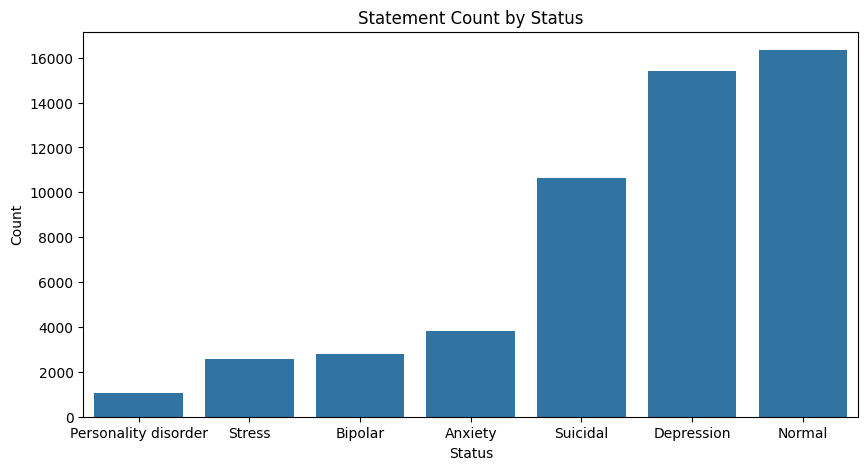

In [8]:
data = df.groupby('status')['statement'].count().sort_values().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=data, x='status', y='statement')
plt.xlabel('Status')
plt.ylabel('Count')
plt.title('Statement Count by Status')
plt.show()

In [9]:
df['status'].value_counts()

,count
status,
Normal,16343
Depression,15404
Suicidal,10652
Anxiety,3841
Bipolar,2777
Stress,2587
Personality disorder,1077


In [10]:
df[df['statement']== 'what do you mean?']

,statement,status
31098,what do you mean?,Normal
31216,what do you mean?,Normal
31377,what do you mean?,Normal
31522,what do you mean?,Normal
31606,what do you mean?,Normal
31675,what do you mean?,Normal
31788,what do you mean?,Normal
31882,what do you mean?,Normal
31981,what do you mean?,Normal
32022,what do you mean?,Normal


# Feature Engineering


In [11]:
df['statement_length'] = df['statement'].apply(len)
df['num_words'] = df['statement'].apply(lambda x: len(x.split()))
df['avg_word_length'] = np.round(df['statement_length'] / df['num_words'])
df['avg_word_length'] = df['avg_word_length'].map(int)
df['vocabulary_size'] = df['statement'].apply(lambda x: len(set(x.split())))
df.head()

,statement,status,statement_length,num_words,avg_word_length,vocabulary_size
0,oh my gosh,Anxiety,10,3,3,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10,6,10
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,14,6,13
3,I've shifted my focus to something else but I'...,Anxiety,61,11,6,11
4,"I'm restless and restless, it's been a month n...",Anxiety,72,14,5,14


In [12]:
num_feature = [feature for feature in df.columns if df[feature].dtype != 'O']

num_feature

['statement_length', 'num_words', 'avg_word_length', 'vocabulary_size']

# Data Preprocessing


In [13]:
df['statement']=df['statement'].str.lower()
df.head(10)

,statement,status,statement_length,num_words,avg_word_length,vocabulary_size
0,oh my gosh,Anxiety,10,3,3,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10,6,10
2,"all wrong, back off dear, forward doubt. stay ...",Anxiety,78,14,6,13
3,i've shifted my focus to something else but i'...,Anxiety,61,11,6,11
4,"i'm restless and restless, it's been a month n...",Anxiety,72,14,5,14
5,"every break, you must be nervous, like somethi...",Anxiety,76,14,5,14
6,"i feel scared, anxious, what can i do? and may...",Anxiety,78,17,5,16
7,have you ever felt nervous but didn't know why?,Anxiety,47,9,5,9
8,"i haven't slept well for 2 days, it's like i'm...",Anxiety,70,14,5,14
9,"i'm really worried, i want to cry.",Anxiety,34,7,5,7


In [14]:
def remove_whitespaces(statement):
    return " ".join(statement.split())
df['statement']=df['statement'].apply(remove_whitespaces)
df.head(10)

,statement,status,statement_length,num_words,avg_word_length,vocabulary_size
0,oh my gosh,Anxiety,10,3,3,3
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,10,6,10
2,"all wrong, back off dear, forward doubt. stay ...",Anxiety,78,14,6,13
3,i've shifted my focus to something else but i'...,Anxiety,61,11,6,11
4,"i'm restless and restless, it's been a month n...",Anxiety,72,14,5,14
5,"every break, you must be nervous, like somethi...",Anxiety,76,14,5,14
6,"i feel scared, anxious, what can i do? and may...",Anxiety,78,17,5,16
7,have you ever felt nervous but didn't know why?,Anxiety,47,9,5,9
8,"i haven't slept well for 2 days, it's like i'm...",Anxiety,70,14,5,14
9,"i'm really worried, i want to cry.",Anxiety,34,7,5,7


In [15]:
import nltk
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Download necessary NLTK data
nltk.download('wordnet')
nltk.download('stopwords')

lemmatizer = WordNetLemmatizer()
# We keep "not" and "no" because "not happy" is very different from "happy"
stop_words = set(stopwords.words('english'))
words_to_keep = {'not', 'no', 'never', 'none', 'cannot', 'neither', 'nor'}
stop_words = stop_words - words_to_keep

def clean_text(text):
    if not isinstance(text, str): return ""
    text = text.lower()
    # Remove special characters but keep essential punctuation if needed
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    # Lemmatize: 'crying' -> 'cry', 'better' -> 'good'
    clean_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return " ".join(clean_tokens)

# Apply to your dataframe
df['clean_statement'] = df['statement'].apply(clean_text)
df.drop('statement',axis=1,inplace=True)
df.head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,status,statement_length,num_words,avg_word_length,vocabulary_size,clean_statement
0,Anxiety,10,3,3,3,oh gosh
1,Anxiety,64,10,6,10,trouble sleeping confused mind restless heart ...
2,Anxiety,78,14,6,13,wrong back dear forward doubt stay restless re...
3,Anxiety,61,11,6,11,ive shifted focus something else im still worried
4,Anxiety,72,14,5,14,im restless restless month boy mean


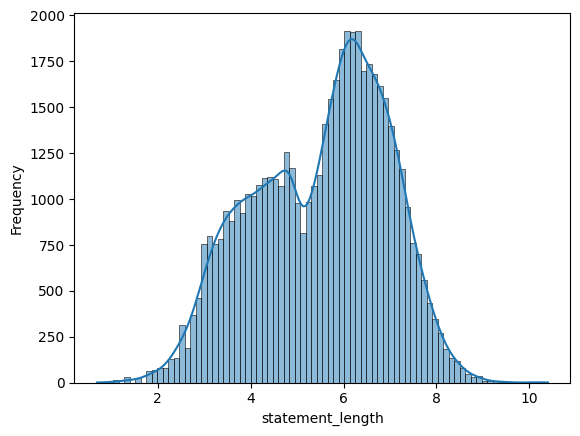

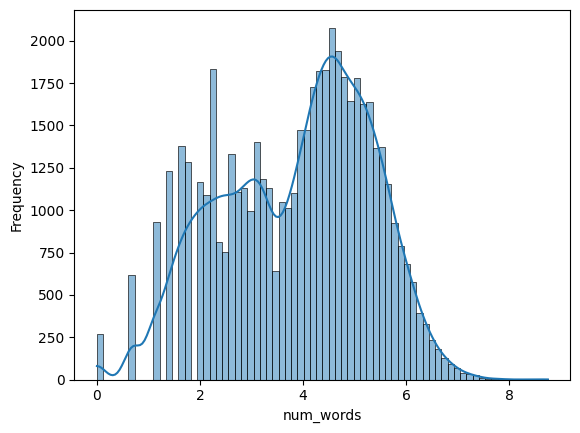

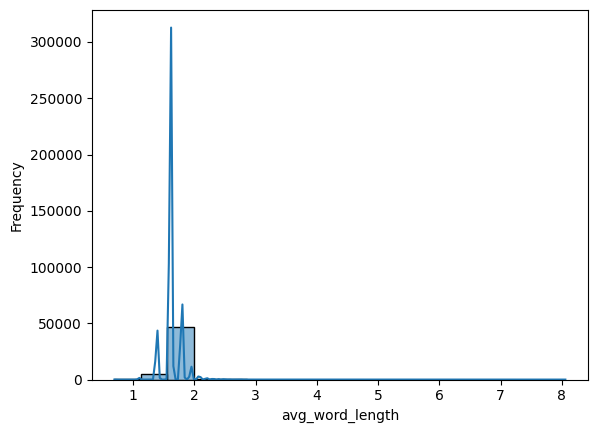

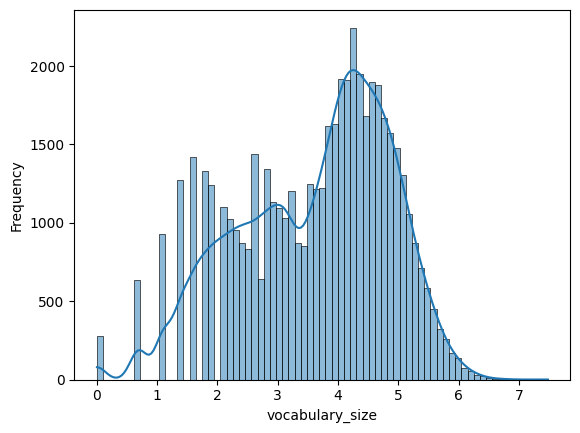

In [16]:
for feature in num_feature:
    data = df.copy()
    data[feature] = np.log(data[feature])
    sns.histplot(data = data, x=feature,kde=True)
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

In [17]:
for feature in num_feature:
    df[feature] = np.log(df[feature])

df.head()

,status,statement_length,num_words,avg_word_length,vocabulary_size,clean_statement
0,Anxiety,2.302585,1.098612,1.098612,1.098612,oh gosh
1,Anxiety,4.158883,2.302585,1.791759,2.302585,trouble sleeping confused mind restless heart ...
2,Anxiety,4.356709,2.639057,1.791759,2.564949,wrong back dear forward doubt stay restless re...
3,Anxiety,4.110874,2.397895,1.791759,2.397895,ive shifted focus something else im still worried
4,Anxiety,4.276666,2.639057,1.609438,2.639057,im restless restless month boy mean


In [18]:
# THE DEFINITIVE MAPPING (Do not change)
label_ordered = {
    'Normal': 0,
    'Depression': 1,
    'Anxiety': 2,
    'Stress': 3,
    'Suicidal': 4,
    'Bipolar': 5,
    'Personality Disorder': 6
}
df['status'] = df['status'].map(label_ordered)
df['status'].unique()

array([ 2.,  0.,  1.,  4.,  3.,  5., nan])

In [19]:
df['status'].value_counts()

,count
status,
0.0,16343
1.0,15404
4.0,10652
2.0,3841
5.0,2777
3.0,2587


# Data Sampling

In [20]:
from sklearn.utils import resample

# Drop rows where 'status' is NaN (due to unmapped 'Personality disorder')
df_cleaned = df.dropna(subset=['status'])

# Get unique status codes present in the cleaned DataFrame
unique_status_codes = df_cleaned['status'].unique()

# Upsample all minority classes to match the 'Normal' count (16343)
df_upsampled = pd.DataFrame()

# Iterate only over the unique status codes that actually exist in the data
for status_code in unique_status_codes:
    class_subset = df_cleaned[df_cleaned['status'] == status_code]
    # Ensure class_subset is not empty before resampling
    if not class_subset.empty:
        resampled_subset = resample(class_subset,
                                    replace=True,     # sample with replacement
                                    n_samples=16343,  # match majority class
                                    random_state=42)
        df_upsampled = pd.concat([df_upsampled, resampled_subset])
    else:
        print(f"Warning: No data for status_code {status_code}. Skipping resampling for this class.")

# Shuffle the new balanced dataset
df_balanced = df_upsampled.sample(frac=1).reset_index(drop=True)

In [21]:
df_balanced['status'].value_counts()

,count
status,
4.0,16343
5.0,16343
0.0,16343
2.0,16343
1.0,16343
3.0,16343


In [22]:
df_balanced

,status,statement_length,num_words,avg_word_length,vocabulary_size,clean_statement
0,4.0,6.486161,4.787492,1.609438,4.465908,know everyone feel unhappy feel deeply unhappy...
1,4.0,7.242798,5.583496,1.609438,5.030438,blacki ugly fucking thinki foolhave no friends...
2,5.0,5.723585,4.158883,1.609438,3.912023,im manic stable well title say im manic right ...
3,0.0,4.574711,2.944439,1.609438,2.944439,gigdiary know wa little depressed ate much las...
4,5.0,6.616065,5.056246,1.609438,4.653960,enjoy hypomania havent slept hour feel amazing...
...,...,...,...,...,...,...
98053,4.0,7.101676,5.493061,1.609438,4.948760,tomorrow st birthday feel miserable not anythi...
98054,3.0,7.275865,5.609472,1.609438,5.123964,missing week college due illness friday woke f...
98055,5.0,7.981733,6.248043,1.791759,5.717028,doesnt get better changed everything everythin...
98056,3.0,4.927254,3.044522,1.945910,2.833213,chronic lifelong stress severe depression anyo...


In [23]:
y = df_balanced['status']

# Tokenization

In [24]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_balanced['clean_statement'])

In [25]:
sequences = tokenizer.texts_to_sequences(df_balanced['clean_statement'])

In [26]:
max_seq_len = 400
X = pad_sequences(sequences, maxlen=max_seq_len)

In [27]:
X_train, X_dummy, y_train, y_dummy = train_test_split(X, y, test_size=0.2, random_state=42)
X_valid, X_test, y_valid, y_test = train_test_split(X_dummy, y_dummy, test_size=0.5, random_state=42)

In [28]:
word_counts = len(tokenizer.word_index) + 1
word_counts

57761

In [29]:
max_seq_length = max(len(seq) for seq in sequences)
max_seq_length

3780

In [30]:
model = Sequential([
    # 1. Embedding Layer
    Embedding(input_dim=word_counts, output_dim=128, input_length=200),

    # 2. First Bi-LSTM Layer (return_sequences=True to stack them)
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),

    # 3. Second Bi-LSTM Layer
    Bidirectional(LSTM(32)),
    Dropout(0.3),

    # 4. Dense Layers
    Dense(32, activation='relu'),
    Dense(7, activation='softmax') # 7 categories
])

model.compile(optimizer='adamax', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [31]:
# Define a class for custom callback
class MyCallback(keras.callbacks.Callback):
    def __init__(self, patience, stop_patience, threshold, factor, initial_epoch, epochs, ask_epoch):
        super(MyCallback, self).__init__()
        self.patience = patience  # epochs without improvement before adjusting lr
        self.stop_patience = stop_patience  # times to adjust lr without improvement before stopping
        self.threshold = threshold  # training accuracy threshold
        self.factor = factor  # factor to reduce lr
        self.initial_epoch = initial_epoch
        self.epochs = epochs
        self.ask_epoch = ask_epoch
        self.ask_epoch_initial = ask_epoch  # save initial ask_epoch

        # Callback variables
        self.count = 0
        self.stop_count = 0
        self.best_epoch = 1
        self.initial_lr = None
        self.highest_tracc = 0.0
        self.lowest_vloss = np.inf
        self.best_weights = None
        self.initial_weights = None

    # Called when training begins
    def on_train_begin(self, logs=None):
        self.initial_lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        self.best_weights = self.model.get_weights()  # safe now
        self.initial_weights = self.model.get_weights()
        msg = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format('Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor','% Improv', 'Duration')
        print(msg)
        self.start_time = time.time()

    # Called when training ends
    def on_train_end(self, logs=None):
        stop_time = time.time()
        tr_duration = stop_time - self.start_time
        hours = tr_duration // 3600
        minutes = (tr_duration - (hours * 3600)) // 60
        seconds = tr_duration - ((hours * 3600) + (minutes * 60))
        msg = f'Training elapsed time was {int(hours)} hours, {minutes:4.1f} minutes, {seconds:4.2f} seconds'
        print(msg)
        self.model.set_weights(self.best_weights)  # restore best weights

    # Called at the end of each batch
    def on_train_batch_end(self, batch, logs=None):
        acc = logs.get('accuracy') * 100
        loss = logs.get('loss')


    # Called at the beginning of each epoch
    def on_epoch_begin(self, epoch, logs=None):
        self.ep_start = time.time()

    # Called at the end of each epoch
    def on_epoch_end(self, epoch, logs=None):
        ep_end = time.time()
        duration = ep_end - self.ep_start

        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        current_lr = lr

        acc = logs.get('accuracy')
        v_acc = logs.get('val_accuracy')
        loss = logs.get('loss')
        v_loss = logs.get('val_loss')

        if acc < self.threshold:
            monitor = 'accuracy'
            pimprov = 0.0 if epoch == 0 else (acc - self.highest_tracc) * 100 / self.highest_tracc

            if acc > self.highest_tracc:
                self.highest_tracc = acc
                self.best_weights = self.model.get_weights()
                self.count = 0
                self.stop_count = 0
                if v_loss < self.lowest_vloss:
                    self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1
            else:
                if self.count >= self.patience - 1:
                    lr = lr * self.factor
                    self.model.optimizer.learning_rate.assign(lr)
                    self.count = 0
                    self.stop_count += 1
                    if v_loss < self.lowest_vloss:
                        self.lowest_vloss = v_loss
                else:
                    self.count += 1
        else:
            monitor = 'val_loss'
            pimprov = 0.0 if epoch == 0 else (self.lowest_vloss - v_loss) * 100 / self.lowest_vloss

            if v_loss < self.lowest_vloss:
                self.lowest_vloss = v_loss
                self.best_weights = self.model.get_weights()
                self.count = 0
                self.stop_count = 0
                self.best_epoch = epoch + 1
            else:
                if self.count >= self.patience - 1:
                    lr = lr * self.factor
                    self.model.optimizer.learning_rate.assign(lr)
                    self.stop_count += 1
                    self.count = 0
                else:
                    self.count += 1
                if acc > self.highest_tracc:
                    self.highest_tracc = acc

        msg = f'{epoch + 1:^3}/{self.epochs:^4} {loss:^9.3f}{acc*100:^9.3f}{v_loss:^9.5f}{v_acc*100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}{monitor:^11}{pimprov:^10.2f}{duration:^8.2f}'
        print(msg)

        if self.stop_count > self.stop_patience - 1:
            msg = f'Training halted at epoch {epoch + 1} after {self.stop_patience} adjustments with no improvement'
            print(msg)
            self.model.stop_training = True
        elif self.ask_epoch is not None and epoch + 1 >= self.ask_epoch:
            msg = 'Enter H to halt training or an integer for number of epochs to run then ask again'
            print(msg)
            ans = input('')
            if ans.lower() == 'h':
                msg = f'Training halted at epoch {epoch + 1} by user input'
                print(msg)
                self.model.stop_training = True
            else:
                try:
                    ans = int(ans)
                    self.ask_epoch += ans
                    msg = f'Training will continue until epoch {self.ask_epoch}'
                    print(msg)
                    header = '{0:^8s}{1:^10s}{2:^9s}{3:^9s}{4:^9s}{5:^9s}{6:^9s}{7:^10s}{8:10s}{9:^8s}'.format(
                        'Epoch', 'Loss', 'Accuracy', 'V_loss', 'V_acc', 'LR', 'Next LR', 'Monitor', '% Improv', 'Duration'
                    )
                    print(header)
                except:
                    print('Invalid input')

In [32]:
batch_size = 512
epochs = 20
patience = 2 		# number of epochs to wait to adjust lr if monitored value does not improve
stop_patience = 3 	# number of epochs to wait before stopping training if monitored value does not improve
threshold = 0.9 	# if train accuracy is < threshhold adjust monitor accuracy, else monitor validation loss
factor = 0.1 		# factor to reduce lr by
ask_epoch = None		# number of epochs to run before asking if you want to halt training
# The "Simple & Fast" version of your custom class
callbacks = [MyCallback(patience= patience,
            stop_patience= stop_patience, threshold= threshold, factor= factor
            ,initial_epoch= 0, epochs= epochs, ask_epoch= ask_epoch )]

In [33]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    epochs=epochs,
    callbacks= callbacks,
    initial_epoch= 0
)

 Epoch     Loss   Accuracy  V_loss    V_acc     LR     Next LR  Monitor  % Improv  Duration
Epoch 1/20
   9/2452 ━━━━━━━━━━━━━━━━━━━━ 1:09:34 2s/step - accuracy: 0.2048 - loss: 1.9209

KeyboardInterrupt: 

In [ ]:
model.save('student_mood_lstm.h5')

In [ ]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Acc')
    plt.plot(epochs, val_acc, 'r', label='Validation Acc')
    plt.title('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

plot_history(history)

In [ ]:
def final_test(sentences):
    inv_map = {v: k for k, v in label_ordered.items()}
    for text in sentences:
        seq = tokenizer.texts_to_sequences([text.lower()])
        padded = pad_sequences(seq, maxlen=200)
        pred = model.predict(padded, verbose=0)
        idx = np.argmax(pred)
        print(f"Text: {text[:50]}... \nPrediction: {inv_map[idx]} ({np.max(pred)*100:.2f}%)\n")

demo_list = [
   "Every time my phone vibrates, I feel a surge of panic like I'm in trouble.",
    "I've started giving away my favorite books and posters; I won't be needing them soon.",
    "I have back-to-back labs, a presentation, and my laptop just died. I’m at my breaking point.",
    "My project is finally done! It took all night but the relief of submitting it is the best.",
    "I hate my best friend right now for not replying, but ten minutes ago I thought they were a saint.",
    "I'm just chilling today, might go grab some butter chicken with my roommates later."
]
final_test(demo_list)

In [ ]:
# FIND THE TRUTH
for i in range(7):
    # Get a few samples from each category to see what they are
    sample_text = df_new[df_new['status'] == i]['statement'].iloc[0]
    print(f"Index {i} is actually: {sample_text[:100]}")